In [2]:
# 加载所需要的包
%matplotlib inline

# scitnific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

import warnings
warnings.filterwarnings('ignore') 

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
# 加载模型
match_task_motion_m4 = hddm.load('match_task_motion_m4.hddm')
match_task_color_m4 = hddm.load('match_task_color_m4.hddm')

## 匹配任务
### p1: 不同难度下，自我与他人的后验分布

#### 运动组

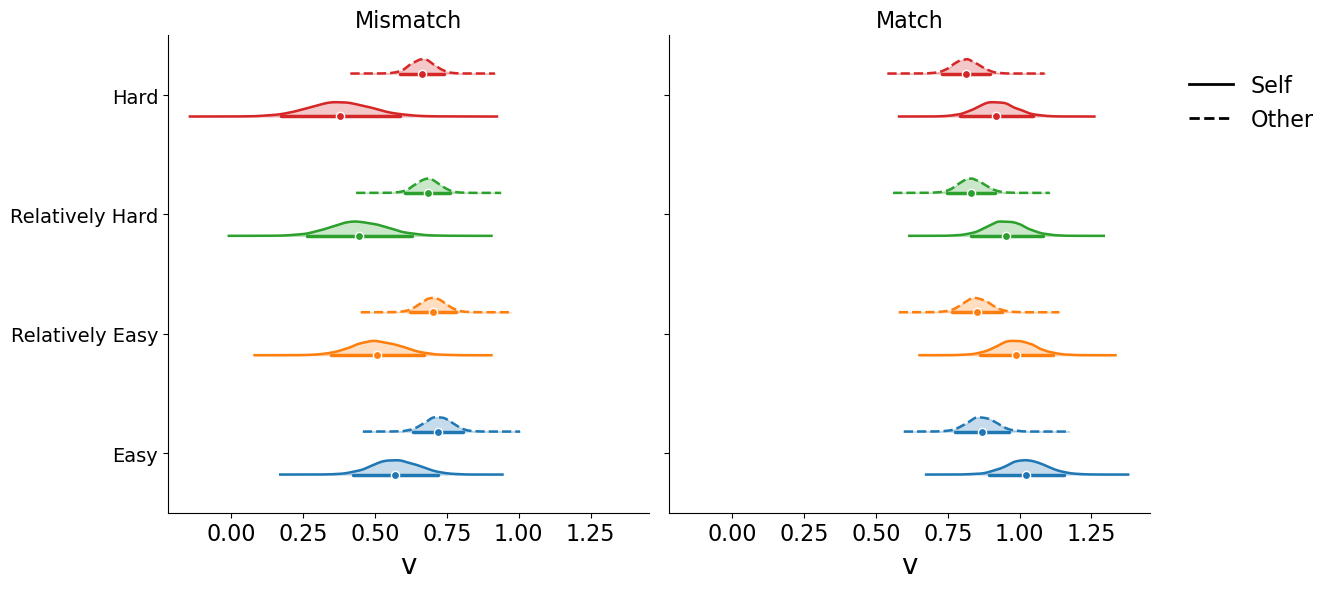

In [16]:
# from scipy.stats import gaussian_kde

# # ========================== 提取后验样本 ==========================
# samples = match_task_motion_m4.posterior_trace_df

# # 提取单个系数变量
# v_Intercept = samples['v_Intercept']
# v_stim = samples['v_stim']
# v_difficulty = samples['v_difficulty']
# v_association_self = samples['v_association[T.self]']
# v_association_stim = samples['v_association[T.self]:stim']
# v_association_difficulty = samples['v_association[T.self]:difficulty']
# v_stim_difficulty = samples['v_stim:difficulty']
# v_association_stim_difficulty = samples['v_association[T.self]:stim:difficulty']

# # ========================== 计算不同条件下的v值 ==========================
# conditions = []

# for stim_cond in ['Match', 'Mismatch']:
#     for diff_level in [1, 2, 3, 4]: # 1=Easy, 4=Hard
#         for assoc_cond in ['Other', 'Self']:
            
#             # 计算难度变化次数：难度1为基准(0次)，难度2加1次，难度3加2次，难度4加3次
#             n_diff_add = diff_level - 1
            
#             # 初始化 v
#             v = None
            
#             # ================= 分条件计算 =================
            
#             if stim_cond == 'Match':
#                 if assoc_cond == 'Other':
#                     # 匹配-他人：
#                     # 基础：v_intercept + v_stim，v_intercept为dc
#                     # 难度：每变化一个单位，加一次 v_difficulty
#                     v = (v_Intercept + v_stim) + (n_diff_add * v_difficulty)
                
#                 else: # Self
#                     # 匹配-自我：
#                     # 基础：v_intercept + v_stim + v_association[T.self] + v_association[T.self]:stim
#                     # stim编码为-1和1，这里的基线是0，所以要加上v_association[T.self]:stim
#                     # 难度：每变化一个单位，加一次 (v_difficulty + v_association[T.self]:difficulty)
#                     v = (v_Intercept + v_stim + v_association_self + v_association_stim) + \
#                         (n_diff_add * (v_difficulty + v_association_difficulty))
            
#             else: # Mismatch
#                 if assoc_cond == 'Other':
#                     # 不匹配-他人：
#                     # 基础：v_intercept + v_stim + v_stim:difficulty #这里加的是不匹配条件基准水平的难度
#                     # 难度：每变化一个单位，加一次 v_difficulty，这是相较于基准水平，难度的变化
#                     v = (v_Intercept + v_stim + v_stim_difficulty) + \
#                         (n_diff_add * v_difficulty)
                
#                 else: # Self
#                     # 不匹配-自我：
#                     # 基础：v_intercept + v_stim + v_stim:difficulty + v_association[T.self] - v_association[T.self]:stim
#                     # 难度：每变化一个单位，加一次 (v_association[T.self]:difficulty + v_association[T.self]:stim:difficulty)
#                     v = (v_Intercept + v_stim + v_stim_difficulty + v_association_self - v_association_stim) + \
#                         (n_diff_add * (v_association_difficulty + v_association_stim_difficulty))
            
#             # 保存结果
#             conditions.append({
#                 'stim': stim_cond,
#                 'difficulty': diff_level,
#                 'association': assoc_cond,
#                 'v_samples': v.values
#             })

# # ========================== 3. 绘图 ==========================
# difficulty_colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
# linestyles = {'Self': '-', 'Other': '--'}
# offset_self = -0.18
# offset_other = 0.18
# scale = 0.12

# fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True, dpi=100)
# stim_list = ['Mismatch', 'Match']

# for ax, stim in zip(axes, stim_list):
#     conds = [c for c in conditions if c['stim'] == stim]
    
#     # 绘制密度脊线
#     for diff in [1, 2, 3, 4]:
#         for assoc in ['Self', 'Other']:
#             match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
#             if not match: continue
#             v_data = match[0]['v_samples']
            
#             kde = gaussian_kde(v_data, bw_method='scott')
#             v_vals = np.linspace(v_data.min() - 0.1, v_data.max() + 0.1, 300)
#             density = kde(v_vals)
#             density_norm = (density / density.max()) * scale
            
#             base_y = diff + (offset_self if assoc == 'Self' else offset_other)
#             y_upper = base_y + density_norm
            
#             ax.fill_between(v_vals, base_y, y_upper, color=difficulty_colors[diff], alpha=0.25)
#             ax.plot(v_vals, y_upper, color=difficulty_colors[diff], linestyle=linestyles[assoc], linewidth=1.8)
    
#     # 添加均值点和 HDI
#     for diff in [1, 2, 3, 4]:
#         for assoc in ['Self', 'Other']:
#             match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
#             if not match: continue
#             v_data = match[0]['v_samples']
#             mean_v = v_data.mean()
#             hdi_low, hdi_high = np.percentile(v_data, [3, 97])
#             y = diff + (offset_self if assoc == 'Self' else offset_other)
            
#             ax.plot([hdi_low, hdi_high], [y, y], color=difficulty_colors[diff], linewidth=2.5, solid_capstyle='round')
#             ax.scatter(mean_v, y, color=difficulty_colors[diff], s=35, edgecolor='white', linewidth=1, zorder=5)
    
#     # 装饰
#     ax.set_title(f'{stim}', fontsize=16)
#     ax.set_xlabel('v', fontsize=20)
#     ax.tick_params(axis='x', labelsize=16)
#     ax.set_yticks([1, 2, 3, 4])
#     ax.set_yticklabels(['Easy', 'Relatively Easy', 'Relatively Hard', 'Hard'], fontsize=14)
#     ax.set_ylim(0.5, 4.5)
    
#     # ================= 关键修改1：去掉上框线和右框线 =================
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# # ================= 关键修改2：简化图例，只保留 Self 和 Other =================
# from matplotlib.lines import Line2D
# legend_elements = [
#     Line2D([0], [0], color='k', lw=2, linestyle='-', label='Self'),
#     Line2D([0], [0], color='k', lw=2, linestyle='--', label='Other')
# ]
# fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.03, 0.9), fontsize=16, frameon=False)

# plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig('Fig/motion_match_v.svg', format='svg', dpi=300, bbox_inches='tight')
# plt.show()

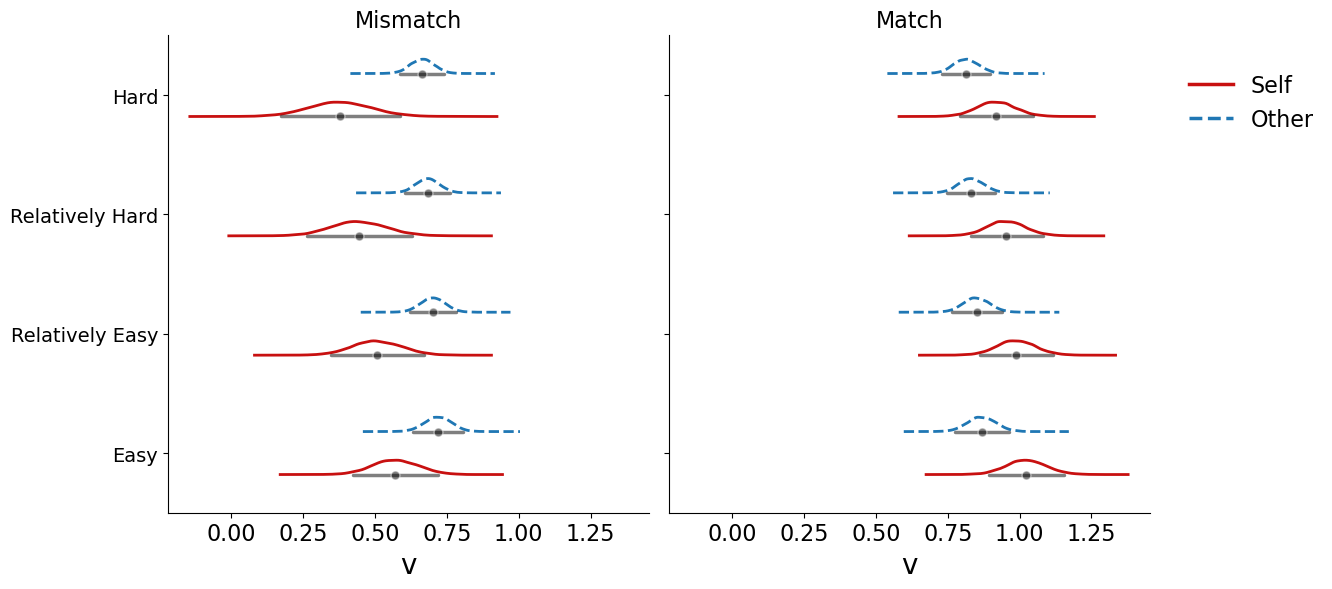

In [37]:
# ========================== 提取后验样本 ==========================
samples = match_task_motion_m4.posterior_trace_df

# 提取单个系数变量
v_Intercept = samples['v_Intercept']
v_stim = samples['v_stim']
v_difficulty = samples['v_difficulty']
v_association_self = samples['v_association[T.self]']
v_association_stim = samples['v_association[T.self]:stim']
v_association_difficulty = samples['v_association[T.self]:difficulty']
v_stim_difficulty = samples['v_stim:difficulty']
v_association_stim_difficulty = samples['v_association[T.self]:stim:difficulty']

# ========================== 计算不同条件下的v值 ==========================
conditions = []

for stim_cond in ['Match', 'Mismatch']:
    for diff_level in [1, 2, 3, 4]:
        for assoc_cond in ['Other', 'Self']:
            
            n_diff_add = diff_level - 1
            
            if stim_cond == 'Match':
                if assoc_cond == 'Other':
                    v = (v_Intercept + v_stim) + (n_diff_add * v_difficulty)
                else:
                    v = (v_Intercept + v_stim + v_association_self + v_association_stim) + \
                        (n_diff_add * (v_difficulty + v_association_difficulty))
            else:
                if assoc_cond == 'Other':
                    v = (v_Intercept + v_stim + v_stim_difficulty) + \
                        (n_diff_add * v_difficulty)
                else:
                    v = (v_Intercept + v_stim + v_stim_difficulty + v_association_self - v_association_stim) + \
                        (n_diff_add * (v_association_difficulty + v_association_stim_difficulty))
            
            conditions.append({
                'stim': stim_cond,
                'difficulty': diff_level,
                'association': assoc_cond,
                'v_samples': v.values
            })

# ========================== 3. 绘图 ==========================
color_self = "#c81010"    # 红色
color_other = "#1f77b4"  # 蓝色
linestyles = {'Self': '-', 'Other': '--'}

offset_self = -0.18
offset_other = 0.18
scale = 0.12

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True, dpi=100)
stim_list = ['Mismatch', 'Match']

for ax, stim in zip(axes, stim_list):
    conds = [c for c in conditions if c['stim'] == stim]
    
    # 绘制密度脊线
    for diff in [1, 2, 3, 4]:
        for assoc in ['Self', 'Other']:
            match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
            if not match: continue
            v_data = match[0]['v_samples']
            
            kde = gaussian_kde(v_data, bw_method='scott')
            v_vals = np.linspace(v_data.min() - 0.1, v_data.max() + 0.1, 300)
            density = kde(v_vals)
            density_norm = (density / density.max()) * scale
            
            base_y = diff + (offset_self if assoc == 'Self' else offset_other)
            y_upper = base_y + density_norm
            
            # 只保留线条
            line_color = color_self if assoc == 'Self' else color_other
            ax.plot(v_vals, y_upper, color=line_color, linestyle=linestyles[assoc], linewidth=2)
    
    # 添加均值点和 HDI 
    for diff in [1, 2, 3, 4]:
        for assoc in ['Self', 'Other']:
            match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
            if not match: continue
            v_data = match[0]['v_samples']
            mean_v = v_data.mean()
            hdi_low, hdi_high = np.percentile(v_data, [3, 97])
            y = diff + (offset_self if assoc == 'Self' else offset_other)
            
            line_color = color_self if assoc == 'Self' else color_other
            ax.plot([hdi_low, hdi_high], [y, y], color='black', alpha=0.5,linewidth=2.5, solid_capstyle='round')
            ax.scatter(mean_v, y, color='black',alpha=0.5, s=40, edgecolor='white', linewidth=1, zorder=5)
    
    # 装饰
    ax.set_title(f'{stim}', fontsize=16)
    ax.set_xlabel('v', fontsize=20)
    ax.tick_params(axis='x', labelsize=16)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(['Easy', 'Relatively Easy', 'Relatively Hard', 'Hard'], fontsize=14)
    ax.set_ylim(0.5, 4.5)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 图例：红实线自我，蓝虚线他人
legend_elements = [
    Line2D([0], [0], color=color_self, lw=2.5, linestyle='-', label='Self'),
    Line2D([0], [0], color=color_other, lw=2.5, linestyle='--', label='Other')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.03, 0.9), fontsize=16, frameon=False)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('Fig/motion_match_v.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

#### 颜色组

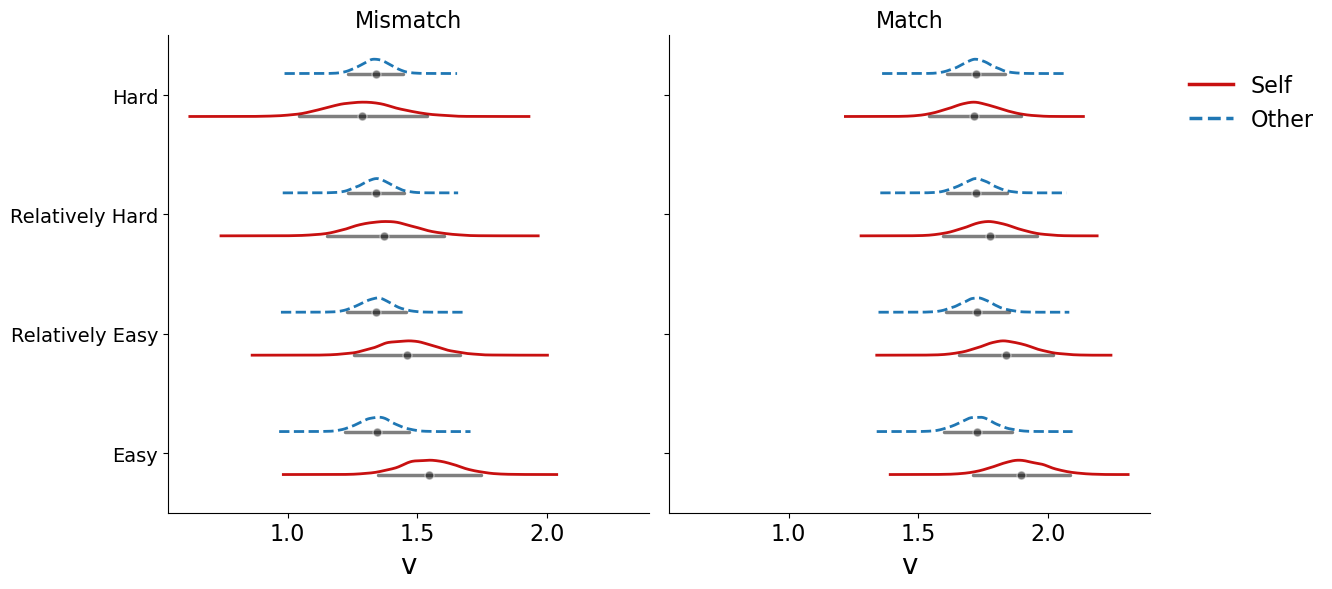

In [38]:
# ========================== 提取后验样本 ==========================
samples = match_task_color_m4.posterior_trace_df

# 提取单个系数变量
v_Intercept = samples['v_Intercept']
v_stim = samples['v_stim']
v_difficulty = samples['v_difficulty']
v_association_self = samples['v_association[T.self]']
v_association_stim = samples['v_association[T.self]:stim']
v_association_difficulty = samples['v_association[T.self]:difficulty']
v_stim_difficulty = samples['v_stim:difficulty']
v_association_stim_difficulty = samples['v_association[T.self]:stim:difficulty']

# ========================== 计算不同条件下的v值 ==========================
conditions = []

for stim_cond in ['Match', 'Mismatch']:
    for diff_level in [1, 2, 3, 4]:
        for assoc_cond in ['Other', 'Self']:
            
            n_diff_add = diff_level - 1
            
            if stim_cond == 'Match':
                if assoc_cond == 'Other':
                    v = (v_Intercept + v_stim) + (n_diff_add * v_difficulty)
                else:
                    v = (v_Intercept + v_stim + v_association_self + v_association_stim) + \
                        (n_diff_add * (v_difficulty + v_association_difficulty))
            else:
                if assoc_cond == 'Other':
                    v = (v_Intercept + v_stim + v_stim_difficulty) + \
                        (n_diff_add * v_difficulty)
                else:
                    v = (v_Intercept + v_stim + v_stim_difficulty + v_association_self - v_association_stim) + \
                        (n_diff_add * (v_association_difficulty + v_association_stim_difficulty))
            
            conditions.append({
                'stim': stim_cond,
                'difficulty': diff_level,
                'association': assoc_cond,
                'v_samples': v.values
            })

# ========================== 3. 绘图 ==========================
color_self = "#c81010"    # 红色
color_other = "#1f77b4"  # 蓝色
linestyles = {'Self': '-', 'Other': '--'}

offset_self = -0.18
offset_other = 0.18
scale = 0.12

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True, dpi=100)
stim_list = ['Mismatch', 'Match']

for ax, stim in zip(axes, stim_list):
    conds = [c for c in conditions if c['stim'] == stim]
    
    # 绘制密度脊线
    for diff in [1, 2, 3, 4]:
        for assoc in ['Self', 'Other']:
            match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
            if not match: continue
            v_data = match[0]['v_samples']
            
            kde = gaussian_kde(v_data, bw_method='scott')
            v_vals = np.linspace(v_data.min() - 0.1, v_data.max() + 0.1, 300)
            density = kde(v_vals)
            density_norm = (density / density.max()) * scale
            
            base_y = diff + (offset_self if assoc == 'Self' else offset_other)
            y_upper = base_y + density_norm
            
            # 只保留线条
            line_color = color_self if assoc == 'Self' else color_other
            ax.plot(v_vals, y_upper, color=line_color, linestyle=linestyles[assoc], linewidth=2)
    
    # 添加均值点和 HDI 
    for diff in [1, 2, 3, 4]:
        for assoc in ['Self', 'Other']:
            match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
            if not match: continue
            v_data = match[0]['v_samples']
            mean_v = v_data.mean()
            hdi_low, hdi_high = np.percentile(v_data, [3, 97])
            y = diff + (offset_self if assoc == 'Self' else offset_other)
            
            line_color = color_self if assoc == 'Self' else color_other
            ax.plot([hdi_low, hdi_high], [y, y], color='black', alpha=0.5,linewidth=2.5, solid_capstyle='round')
            ax.scatter(mean_v, y, color='black',alpha=0.5, s=40, edgecolor='white', linewidth=1, zorder=5)
    
    # 装饰
    ax.set_title(f'{stim}', fontsize=16)
    ax.set_xlabel('v', fontsize=20)
    ax.tick_params(axis='x', labelsize=16)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(['Easy', 'Relatively Easy', 'Relatively Hard', 'Hard'], fontsize=14)
    ax.set_ylim(0.5, 4.5)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 图例：红实线自我，蓝虚线他人
legend_elements = [
    Line2D([0], [0], color=color_self, lw=2.5, linestyle='-', label='Self'),
    Line2D([0], [0], color=color_other, lw=2.5, linestyle='--', label='Other')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.03, 0.9), fontsize=16, frameon=False)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('Fig/color_match_v.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

### p2：偏差参数结果

#### 运动组

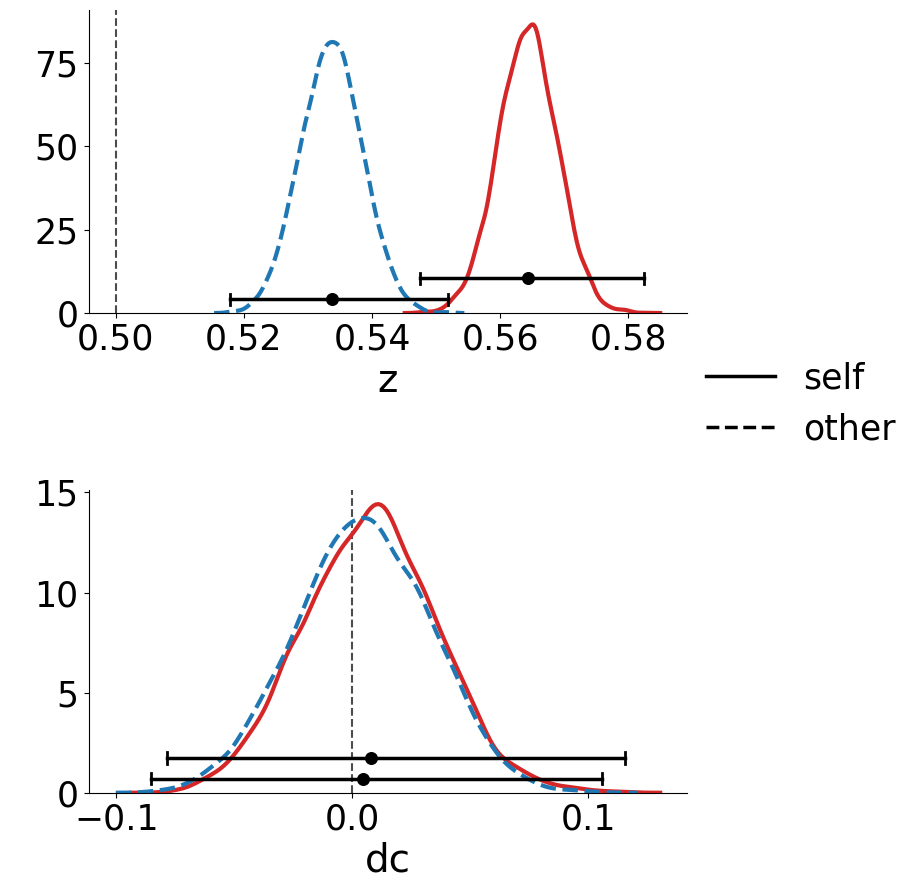

In [31]:
# =====================
# 1. 数据计算
# =====================
trace = match_task_motion_m4.get_traces()

# z (转换后)
z_self = 1 / (1 + np.exp(-trace["z_trans(self)"]))
z_other = 1 / (1 + np.exp(-trace["z_trans(other)"]))

# dc (不用转换)
v_intercept = trace["v_Intercept"]
v_self_effect = trace["v_association[T.self]"]
dc_other = v_intercept
dc_self  = v_intercept + v_self_effect

# =====================
# 2. HDI 函数
# =====================
def hdi(samples, prob=0.95):
    sorted_samples = np.sort(samples)
    n = len(samples)
    gap = int(n * prob)
    min_hdi = sorted_samples[:n-gap].min()
    max_hdi = sorted_samples[gap:].max()
    return min_hdi, max_hdi

# =====================
# 3. 绘图函数
# =====================
def plot_posterior(ax, data, color, label, is_self):
    linestyle = "-" if is_self else "--"
    
    kde_plot = sns.kdeplot(data, color=color, linewidth=3, linestyle=linestyle, ax=ax, label=label)
    kde_line = kde_plot.lines[-1]
    y_max = kde_line.get_ydata().max()
    
    y_hdi = y_max * 0.12 if is_self else y_max * 0.05
    
    mean_val = np.mean(data)
    h_low, h_high = hdi(data)
    
    ax.scatter(mean_val, y_hdi, color="black", s=70, zorder=5)
    ax.plot([h_low, h_high], [y_hdi, y_hdi], color="black", linewidth=2.5, zorder=4)
    ax.plot([h_low, h_low], [y_hdi-0.02*y_max, y_hdi+0.02*y_max], color="black", linewidth=2)
    ax.plot([h_high, h_high], [y_hdi-0.02*y_max, y_hdi+0.02*y_max], color="black", linewidth=2)

# =====================
# 4. 画图（全中文 + 无框线 + 无网格 + 统一红蓝）
# =====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

# --------------------
# 子图1：z 决策偏差
# --------------------
ax1.axvline(0.5, linestyle="--", c="black", alpha=0.7, linewidth=1.5)
plot_posterior(ax1, z_self, "#d62728", "self", is_self=True)
plot_posterior(ax1, z_other, "#1f77b4", "other", is_self=False)

ax1.set_xlabel("z", fontsize=28)
ax1.set_ylabel(" ", fontsize=14)
ax1.tick_params(axis='x', labelsize=25)
ax1.tick_params(axis='y', labelsize=25)
# ax1.set_title("决策偏差后验分布", fontsize=15, weight="bold")
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='self'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label='other')
]
ax1.legend(handles=legend_elements, fontsize=25, frameon=False, loc='right', bbox_to_anchor=(1.4, -0.3))
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(False)

# --------------------
# 子图2：dc 漂移率
# --------------------
ax2.axvline(0, linestyle="--", c="black", alpha=0.7, linewidth=1.5)
plot_posterior(ax2, dc_self, "#d62728", "self", is_self=True)
plot_posterior(ax2, dc_other, "#1f77b4", "other", is_self=False)

ax2.set_xlabel("dc", fontsize=28)
ax2.set_ylabel(" ", fontsize=14)
ax2.tick_params(axis='x', labelsize=25)
ax2.tick_params(axis='y', labelsize=25)
# ax2.set_title("漂移率后验分布", fontsize=15, weight="bold")
# ax2.legend(fontsize=16, frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.savefig('Fig/motion_match_bias.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# 计算所有数值
z1_low, z1_high = hdi(z_self)
z2_low, z2_high = hdi(z_other)
dc1_low, dc1_high = hdi(dc_self)
dc2_low, dc2_high = hdi(dc_other)

z1_mean = np.mean(z_self)
z2_mean = np.mean(z_other)
dc1_mean = np.mean(dc_self)
dc2_mean = np.mean(dc_other)

# 输出（均值 + 95% HDI）
print("======================")
print(f"z(self)   均值 = {z1_mean:.3f}  |  95% HDI = [{z1_low:.3f}, {z1_high:.3f}]")
print(f"z(other)  均值 = {z2_mean:.3f}  |  95% HDI = [{z2_low:.3f}, {z2_high:.3f}]")
print("----------------------")
print(f"dc(self)  均值 = {dc1_mean:.3f}  |  95% HDI = [{dc1_low:.3f}, {dc1_high:.3f}]")
print(f"dc(other) 均值 = {dc2_mean:.3f}  |  95% HDI = [{dc2_low:.3f}, {dc2_high:.3f}]")
print("======================")

z(self)   均值 = 0.564  |  95% HDI = [0.548, 0.583]
z(other)  均值 = 0.534  |  95% HDI = [0.518, 0.552]
----------------------
dc(self)  均值 = 0.008  |  95% HDI = [-0.079, 0.116]
dc(other) 均值 = 0.005  |  95% HDI = [-0.085, 0.106]


#### 颜色组

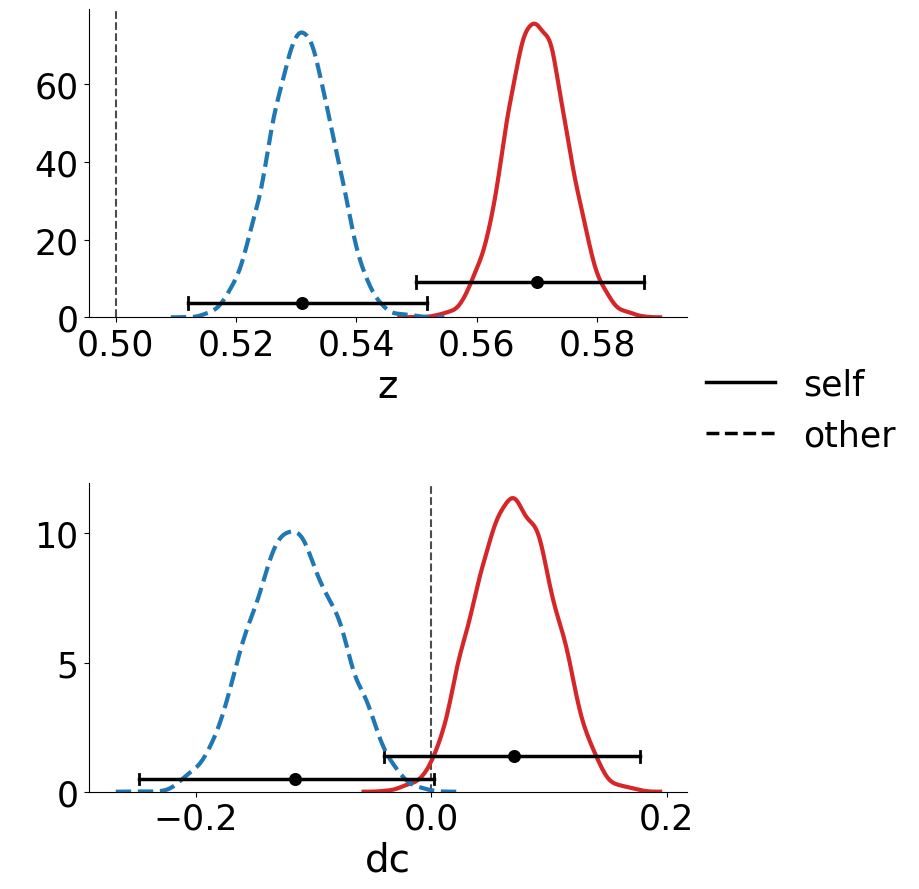

In [32]:
# =====================
# 1. 数据计算
# =====================
trace = match_task_color_m4.get_traces()

# z (转换后)
z_self = 1 / (1 + np.exp(-trace["z_trans(self)"]))
z_other = 1 / (1 + np.exp(-trace["z_trans(other)"]))

# dc (不用转换)
v_intercept = trace["v_Intercept"]
v_self_effect = trace["v_association[T.self]"]
dc_other = v_intercept
dc_self  = v_intercept + v_self_effect

# =====================
# 2. HDI 函数
# =====================
def hdi(samples, prob=0.95):
    sorted_samples = np.sort(samples)
    n = len(samples)
    gap = int(n * prob)
    min_hdi = sorted_samples[:n-gap].min()
    max_hdi = sorted_samples[gap:].max()
    return min_hdi, max_hdi

# =====================
# 3. 绘图函数
# =====================
def plot_posterior(ax, data, color, label, is_self):
    linestyle = "-" if is_self else "--"
    
    kde_plot = sns.kdeplot(data, color=color, linewidth=3, linestyle=linestyle, ax=ax, label=label)
    kde_line = kde_plot.lines[-1]
    y_max = kde_line.get_ydata().max()
    
    y_hdi = y_max * 0.12 if is_self else y_max * 0.05
    
    mean_val = np.mean(data)
    h_low, h_high = hdi(data)
    
    ax.scatter(mean_val, y_hdi, color="black", s=70, zorder=5)
    ax.plot([h_low, h_high], [y_hdi, y_hdi], color="black", linewidth=2.5, zorder=4)
    ax.plot([h_low, h_low], [y_hdi-0.02*y_max, y_hdi+0.02*y_max], color="black", linewidth=2)
    ax.plot([h_high, h_high], [y_hdi-0.02*y_max, y_hdi+0.02*y_max], color="black", linewidth=2)

# =====================
# 4. 画图（全中文 + 无框线 + 无网格 + 统一红蓝）
# =====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

# --------------------
# 子图1：z 决策偏差
# --------------------
ax1.axvline(0.5, linestyle="--", c="black", alpha=0.7, linewidth=1.5)
plot_posterior(ax1, z_self, "#d62728", "self", is_self=True)
plot_posterior(ax1, z_other, "#1f77b4", "other", is_self=False)

ax1.set_xlabel("z", fontsize=28)
ax1.set_ylabel(" ", fontsize=14)
ax1.tick_params(axis='x', labelsize=25)
ax1.tick_params(axis='y', labelsize=25)
# ax1.set_title("决策偏差后验分布", fontsize=15, weight="bold")
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='self'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label='other')
]
ax1.legend(handles=legend_elements, fontsize=25, frameon=False, loc='right', bbox_to_anchor=(1.4, -0.3))
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(False)

# --------------------
# 子图2：dc 漂移率
# --------------------
ax2.axvline(0, linestyle="--", c="black", alpha=0.7, linewidth=1.5)
plot_posterior(ax2, dc_self, "#d62728", "self", is_self=True)
plot_posterior(ax2, dc_other, "#1f77b4", "other", is_self=False)

ax2.set_xlabel("dc", fontsize=28)
ax2.set_ylabel(" ", fontsize=14)
ax2.tick_params(axis='x', labelsize=25)
ax2.tick_params(axis='y', labelsize=25)
# ax2.set_title("漂移率后验分布", fontsize=15, weight="bold")
# ax2.legend(fontsize=16, frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.savefig('Fig/color_match_bias.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# 计算所有数值
z1_low, z1_high = hdi(z_self)
z2_low, z2_high = hdi(z_other)
dc1_low, dc1_high = hdi(dc_self)
dc2_low, dc2_high = hdi(dc_other)

z1_mean = np.mean(z_self)
z2_mean = np.mean(z_other)
dc1_mean = np.mean(dc_self)
dc2_mean = np.mean(dc_other)

# 输出（均值 + 95% HDI）
print("======================")
print(f"z(self)   均值 = {z1_mean:.3f}  |  95% HDI = [{z1_low:.3f}, {z1_high:.3f}]")
print(f"z(other)  均值 = {z2_mean:.3f}  |  95% HDI = [{z2_low:.3f}, {z2_high:.3f}]")
print("----------------------")
print(f"dc(self)  均值 = {dc1_mean:.3f}  |  95% HDI = [{dc1_low:.3f}, {dc1_high:.3f}]")
print(f"dc(other) 均值 = {dc2_mean:.3f}  |  95% HDI = [{dc2_low:.3f}, {dc2_high:.3f}]")
print("======================")

z(self)   均值 = 0.570  |  95% HDI = [0.550, 0.588]
z(other)  均值 = 0.531  |  95% HDI = [0.512, 0.552]
----------------------
dc(self)  均值 = 0.071  |  95% HDI = [-0.040, 0.177]
dc(other) 均值 = -0.116  |  95% HDI = [-0.248, 0.003]


## 辨别任务

In [3]:
# 加载模型
rdk_task_motion_m2 = hddm.load('rdk_task_motion_m2.hddm')
rdk_task_color_m2 = hddm.load('rdk_task_color_m2.hddm')

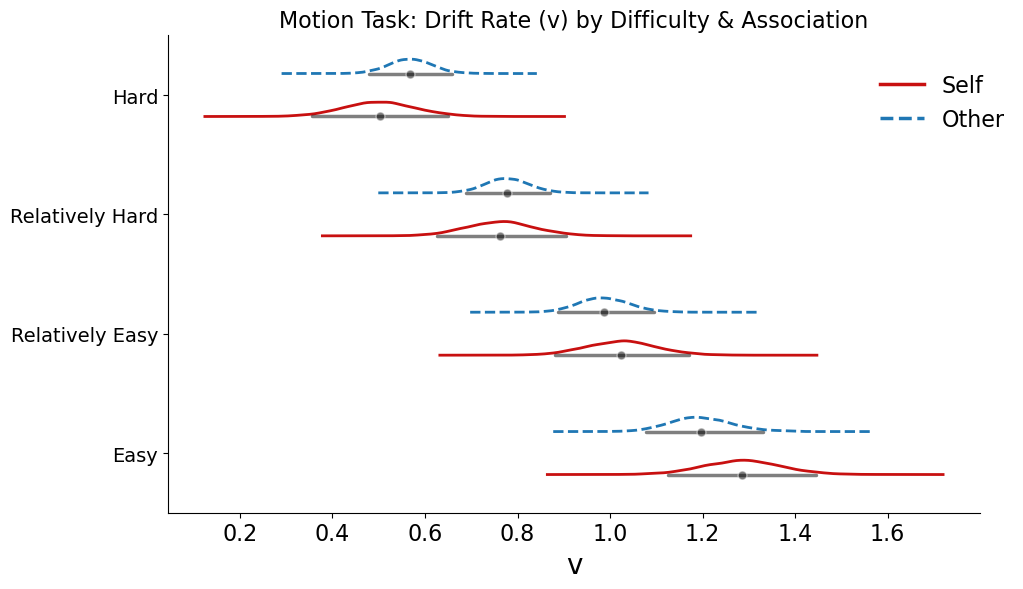

In [4]:
# ========================== 提取后验样本 ==========================
samples = rdk_task_motion_m2.posterior_trace_df

# 提取单个系数变量
v_Intercept = samples['v_Intercept']
v_difficulty = samples['v_difficulty']
v_association_self = samples['v_association[T.self]']
v_association_difficulty = samples['v_association[T.self]:difficulty']

# ========================== 计算不同条件下的v值 ==========================
conditions = []

for diff_level in [1, 2, 3, 4]:
    for assoc_cond in ['Other', 'Self']:
        n_diff_add = diff_level - 1
        
        if assoc_cond == 'Other':
            v = v_Intercept + (n_diff_add * v_difficulty)
        else:
            v = (v_Intercept + v_association_self) + \
                (n_diff_add * (v_difficulty + v_association_difficulty))

        conditions.append({
            'difficulty': diff_level,
            'association': assoc_cond,
            'v_samples': v.values
        })

# ========================== 绘图 ==========================
color_self = "#c81010"    # 红色
color_other = "#1f77b4"  # 蓝色
linestyles = {'Self': '-', 'Other': '--'}

offset_self = -0.18
offset_other = 0.18
scale = 0.12

# 单图 (1,1)
fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True, sharey=True, dpi=100)

# 绘制密度脊线
for diff in [1, 2, 3, 4]:
    for assoc in ['Self', 'Other']:
        match = [c for c in conditions if c['difficulty'] == diff and c['association'] == assoc]
        if not match: continue
        v_data = match[0]['v_samples']
        
        kde = gaussian_kde(v_data, bw_method='scott')
        v_vals = np.linspace(v_data.min() - 0.1, v_data.max() + 0.1, 300)
        density = kde(v_vals)
        density_norm = (density / density.max()) * scale
        
        base_y = diff + (offset_self if assoc == 'Self' else offset_other)
        y_upper = base_y + density_norm
        
        line_color = color_self if assoc == 'Self' else color_other
        ax.plot(v_vals, y_upper, color=line_color, linestyle=linestyles[assoc], linewidth=2)

# 添加均值点和 HDI
for diff in [1, 2, 3, 4]:
    for assoc in ['Self', 'Other']:
        match = [c for c in conditions if c['difficulty'] == diff and c['association'] == assoc]
        if not match: continue
        v_data = match[0]['v_samples']
        mean_v = v_data.mean()
        hdi_low, hdi_high = np.percentile(v_data, [3, 97])
        y = diff + (offset_self if assoc == 'Self' else offset_other)
        
        ax.plot([hdi_low, hdi_high], [y, y], color='black', alpha=0.5, linewidth=2.5, solid_capstyle='round')
        ax.scatter(mean_v, y, color='black', alpha=0.5, s=40, edgecolor='white', linewidth=1, zorder=5)

# 装饰
ax.set_title('Motion Task: Drift Rate (v) by Difficulty & Association', fontsize=16)
ax.set_xlabel('v', fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['Easy', 'Relatively Easy', 'Relatively Hard', 'Hard'], fontsize=14)
ax.set_ylim(0.5, 4.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 图例
legend_elements = [
    Line2D([0], [0], color=color_self, lw=2.5, linestyle='-', label='Self'),
    Line2D([0], [0], color=color_other, lw=2.5, linestyle='--', label='Other')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.03, 0.9), fontsize=16, frameon=False)

plt.tight_layout()
plt.savefig('Fig/motion_rdk_v.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

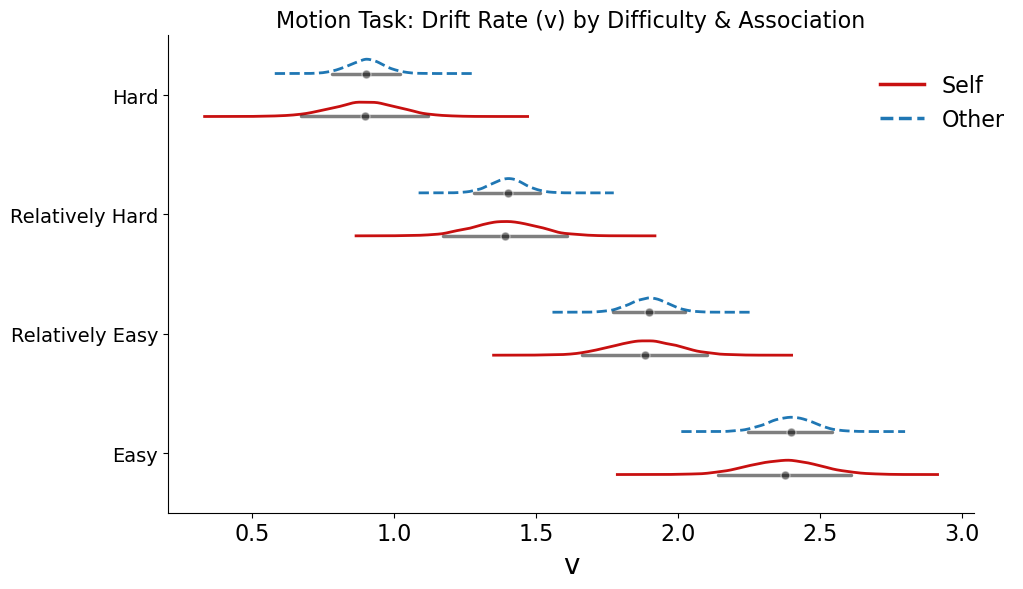

In [5]:
# ========================== 提取后验样本 ==========================
samples = rdk_task_color_m2.posterior_trace_df

# 提取单个系数变量
v_Intercept = samples['v_Intercept']
v_difficulty = samples['v_difficulty']
v_association_self = samples['v_association[T.self]']
v_association_difficulty = samples['v_association[T.self]:difficulty']

# ========================== 计算不同条件下的v值 ==========================
conditions = []

for diff_level in [1, 2, 3, 4]:
    for assoc_cond in ['Other', 'Self']:
        n_diff_add = diff_level - 1
        
        if assoc_cond == 'Other':
            v = v_Intercept + (n_diff_add * v_difficulty)
        else:
            v = (v_Intercept + v_association_self) + \
                (n_diff_add * (v_difficulty + v_association_difficulty))

        conditions.append({
            'difficulty': diff_level,
            'association': assoc_cond,
            'v_samples': v.values
        })

# ========================== 绘图 ==========================
color_self = "#c81010"    # 红色
color_other = "#1f77b4"  # 蓝色
linestyles = {'Self': '-', 'Other': '--'}

offset_self = -0.18
offset_other = 0.18
scale = 0.12

# 单图 (1,1)
fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True, sharey=True, dpi=100)

# 绘制密度脊线
for diff in [1, 2, 3, 4]:
    for assoc in ['Self', 'Other']:
        match = [c for c in conditions if c['difficulty'] == diff and c['association'] == assoc]
        if not match: continue
        v_data = match[0]['v_samples']
        
        kde = gaussian_kde(v_data, bw_method='scott')
        v_vals = np.linspace(v_data.min() - 0.1, v_data.max() + 0.1, 300)
        density = kde(v_vals)
        density_norm = (density / density.max()) * scale
        
        base_y = diff + (offset_self if assoc == 'Self' else offset_other)
        y_upper = base_y + density_norm
        
        line_color = color_self if assoc == 'Self' else color_other
        ax.plot(v_vals, y_upper, color=line_color, linestyle=linestyles[assoc], linewidth=2)

# 添加均值点和 HDI
for diff in [1, 2, 3, 4]:
    for assoc in ['Self', 'Other']:
        match = [c for c in conditions if c['difficulty'] == diff and c['association'] == assoc]
        if not match: continue
        v_data = match[0]['v_samples']
        mean_v = v_data.mean()
        hdi_low, hdi_high = np.percentile(v_data, [3, 97])
        y = diff + (offset_self if assoc == 'Self' else offset_other)
        
        ax.plot([hdi_low, hdi_high], [y, y], color='black', alpha=0.5, linewidth=2.5, solid_capstyle='round')
        ax.scatter(mean_v, y, color='black', alpha=0.5, s=40, edgecolor='white', linewidth=1, zorder=5)

# 装饰
ax.set_title('Motion Task: Drift Rate (v) by Difficulty & Association', fontsize=16)
ax.set_xlabel('v', fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['Easy', 'Relatively Easy', 'Relatively Hard', 'Hard'], fontsize=14)
ax.set_ylim(0.5, 4.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 图例
legend_elements = [
    Line2D([0], [0], color=color_self, lw=2.5, linestyle='-', label='Self'),
    Line2D([0], [0], color=color_other, lw=2.5, linestyle='--', label='Other')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.03, 0.9), fontsize=16, frameon=False)

plt.tight_layout()
plt.savefig('Fig/color_rdk_v.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()